# Dupi

## 0. 环境准备

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 设置 rcParams 默认值
import matplotlib
matplotlib.rc("font",family='Microsoft YaHei')

sns.set_style("whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc("axes",
        labelweight="bold", # 标签粗细
        labelsize="large", # 标签字体
        titleweight="bold", # 标题粗细
        titlesize=16, # 标题字体
        titlepad=10,
      )
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

## 1. 数据接入

###  1.1. 读取数据

In [3]:
df_raw = pd.read_csv('../../data/SNF_n6m_dupi_monthly.csv')
df_raw = df_raw[df_raw['prodmdmcode'].isin([162, 169, 193])]
df_raw.head()

,bizym,prodmdmcode,tomdphncode,qty
0,202201,162,PHN00041938,1.0
1,202201,162,PHN00042165,1.0
2,202201,162,PHN00042570,2.0
3,202201,162,PHN00045416,8.0
4,202201,162,PHN00051613,6.0


###  1.2. 格式转换

In [4]:
# 产品编码转换为字符型
df_raw['prodmdmcode'] = df_raw['prodmdmcode'].astype(str)

# 日期转换为字符型
df_raw['bizym'] = pd.to_datetime(df_raw['bizym'].astype(str), format='%Y%m', errors='coerce')

# 销量转换为数值型
if 'qty' in df_raw.columns:
    df_raw['qty'] = pd.to_numeric(df_raw['qty'], errors='coerce')

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130288 entries, 0 to 130287
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   bizym        130288 non-null  datetime64[ns]
 1   prodmdmcode  130288 non-null  object        
 2   tomdphncode  130288 non-null  object        
 3   qty          130288 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 4.0+ MB


## 2. 162规格价格处理

### 2.1. 数据准备

In [5]:
df = df_raw[df_raw['prodmdmcode'] == '162'].groupby('bizym', as_index=False).agg(
    当期总销量=('qty', 'sum'),
    当期活跃医院数=('tomdphncode', 'nunique')
).sort_values('bizym').reset_index(drop=True)

df['季度'] = df['bizym'].dt.quarter

SPRING_FESTIVAL = {2022:2, 2023:1, 2024:2, 2025:1, 2026:2, 2027:2, 2028:1, 2029:2, 2030:2}
df['是否春节月'] = df['bizym'].apply(
    lambda d: int(SPRING_FESTIVAL.get(d.year) == d.month)
)

### 2.2. 价格标注

In [6]:
PRICE_STEPS = [
    (pd.Timestamp('2024-01-01'), 3160.0),
    (pd.Timestamp('2025-01-01'), 2780.0),
    (pd.Timestamp('2099-01-01'), 1510.0),
]
def get_price(d):
    for cutoff, price in PRICE_STEPS:
        if d < cutoff:
            return price
    return PRICE_STEPS[-1][1]

df['当期价格'] = df['bizym'].apply(get_price)
df['价格变动'] = df['当期价格'].diff()
df['是否降价月'] = (df['价格变动'] < -100).astype(int)
df['价格区间ID'] = df['是否降价月'].cumsum()

print(df[['bizym','当期价格','价格区间ID','是否降价月','当期总销量','当期活跃医院数']].to_string(index=False))

     bizym   当期价格  价格区间ID  是否降价月     当期总销量  当期活跃医院数
2022-01-01 3160.0       0      0  14910.50      928
2022-02-01 3160.0       0      0  10964.50      876
2022-03-01 3160.0       0      0  16957.50     1130
2022-04-01 3160.0       0      0  14229.50     1032
2022-05-01 3160.0       0      0  15979.50     1065
2022-06-01 3160.0       0      0  20915.00     1191
2022-07-01 3160.0       0      0  18726.50     1164
2022-08-01 3160.0       0      0  21877.00     1252
2022-09-01 3160.0       0      0  29061.00     1287
2022-10-01 3160.0       0      0  14643.00     1126
2022-11-01 3160.0       0      0  20072.50     1214
2022-12-01 3160.0       0      0  14014.50     1089
2023-01-01 3160.0       0      0  19668.00     1101
2023-02-01 3160.0       0      0  18661.00     1201
2023-03-01 3160.0       0      0  37830.50     1982
2023-04-01 3160.0       0      0  24692.50     1423
2023-05-01 3160.0       0      0  34308.75     1582
2023-06-01 3160.0       0      0  37550.50     1570
2023-07-01 3

### 2.3. 自然增长率估计

In [7]:
df0 = df[df['价格区间ID'] == 0].copy()
df0['年份'] = df0['bizym'].dt.year

annual_growth_rate = (
    df0.groupby('年份')
       .agg(单院销量=('当期总销量', lambda x: x.mean() / df0.loc[x.index, '当期活跃医院数'].mean()))
       .pct_change()
       ['单院销量']
       .dropna()
       .median()
)
if np.isnan(annual_growth_rate):
    annual_growth_rate = 0.20

BASE_PRICE  = df0['当期价格'].mean()
BASE_QTY    = df0['当期总销量'].mean()
BASE_HOSP   = df0['当期活跃医院数'].mean()
BASE_YEAR   = df0['bizym'].dt.year.min()

print(f"年自然增长率: {annual_growth_rate:.2%}")
print(f"基准价格: {BASE_PRICE:.0f}元 | 基准销量: {BASE_QTY:,.0f} | 基准医院数: {BASE_HOSP:.0f} | 基准年份: {BASE_YEAR}")

年自然增长率: 31.38%
基准价格: 3160元 | 基准销量: 24,941 | 基准医院数: 1327 | 基准年份: 2022


### 2.4. 价格效应拆解

In [8]:
records = []
for gid, gdf in df.groupby('价格区间ID'):
    avg_qty  = gdf['当期总销量'].mean()
    avg_hosp = gdf['当期活跃医院数'].mean()
    avg_price = gdf['当期价格'].mean()
    yr = gdf['bizym'].dt.year.min()

    if gid == 0:
        nat_coef, price_mult = 1.0, 1.0
    else:
        nat_coef   = (avg_hosp / BASE_HOSP) * (1 + annual_growth_rate) ** (yr - BASE_YEAR)
        price_mult = (avg_qty / BASE_QTY) / nat_coef

    records.append({'价格区间ID': gid, '区间均价': avg_price,
                    '自然增长系数': nat_coef, '价格效应倍数': price_mult})

df_coef = pd.DataFrame(records).set_index('价格区间ID')
print(df_coef.round(3))

          区间均价  自然增长系数  价格效应倍数
价格区间ID                        
0       3160.0   1.000   1.000
1       2780.0   2.673   0.862
2       1510.0   4.443   0.815


### 2.5. 将销量映射到基准水平

In [9]:
df['价格效应倍数'] = df['价格区间ID'].map(df_coef['价格效应倍数'])
df['销量_基准']   = df['当期总销量'] / df['价格效应倍数']
df['调整幅度%']   = (df['当期总销量'] / df['销量_基准'] - 1) * 100

cols = ['bizym','当期价格','价格区间ID','当期总销量','销量_基准','调整幅度%','是否降价月']
print(df[cols].to_string(index=False, float_format='%.1f'))

print(f"\n原始销量均值: {df['当期总销量'].mean():,.0f}")
print(f"基准销量均值: {df['销量_基准'].mean():,.0f}")
print(f"平均调整幅度: {df['调整幅度%'].mean():.1f}%  |  最大: {df['调整幅度%'].max():.1f}%")

     bizym   当期价格  价格区间ID    当期总销量    销量_基准  调整幅度%  是否降价月
2022-01-01 3160.0       0  14910.5  14910.5    0.0      0
2022-02-01 3160.0       0  10964.5  10964.5    0.0      0
2022-03-01 3160.0       0  16957.5  16957.5    0.0      0
2022-04-01 3160.0       0  14229.5  14229.5    0.0      0
2022-05-01 3160.0       0  15979.5  15979.5    0.0      0
2022-06-01 3160.0       0  20915.0  20915.0    0.0      0
2022-07-01 3160.0       0  18726.5  18726.5    0.0      0
2022-08-01 3160.0       0  21877.0  21877.0    0.0      0
2022-09-01 3160.0       0  29061.0  29061.0    0.0      0
2022-10-01 3160.0       0  14643.0  14643.0    0.0      0
2022-11-01 3160.0       0  20072.5  20072.5    0.0      0
2022-12-01 3160.0       0  14014.5  14014.5    0.0      0
2023-01-01 3160.0       0  19668.0  19668.0    0.0      0
2023-02-01 3160.0       0  18661.0  18661.0    0.0      0
2023-03-01 3160.0       0  37830.5  37830.5    0.0      0
2023-04-01 3160.0       0  24692.5  24692.5    0.0      0
2023-05-01 316

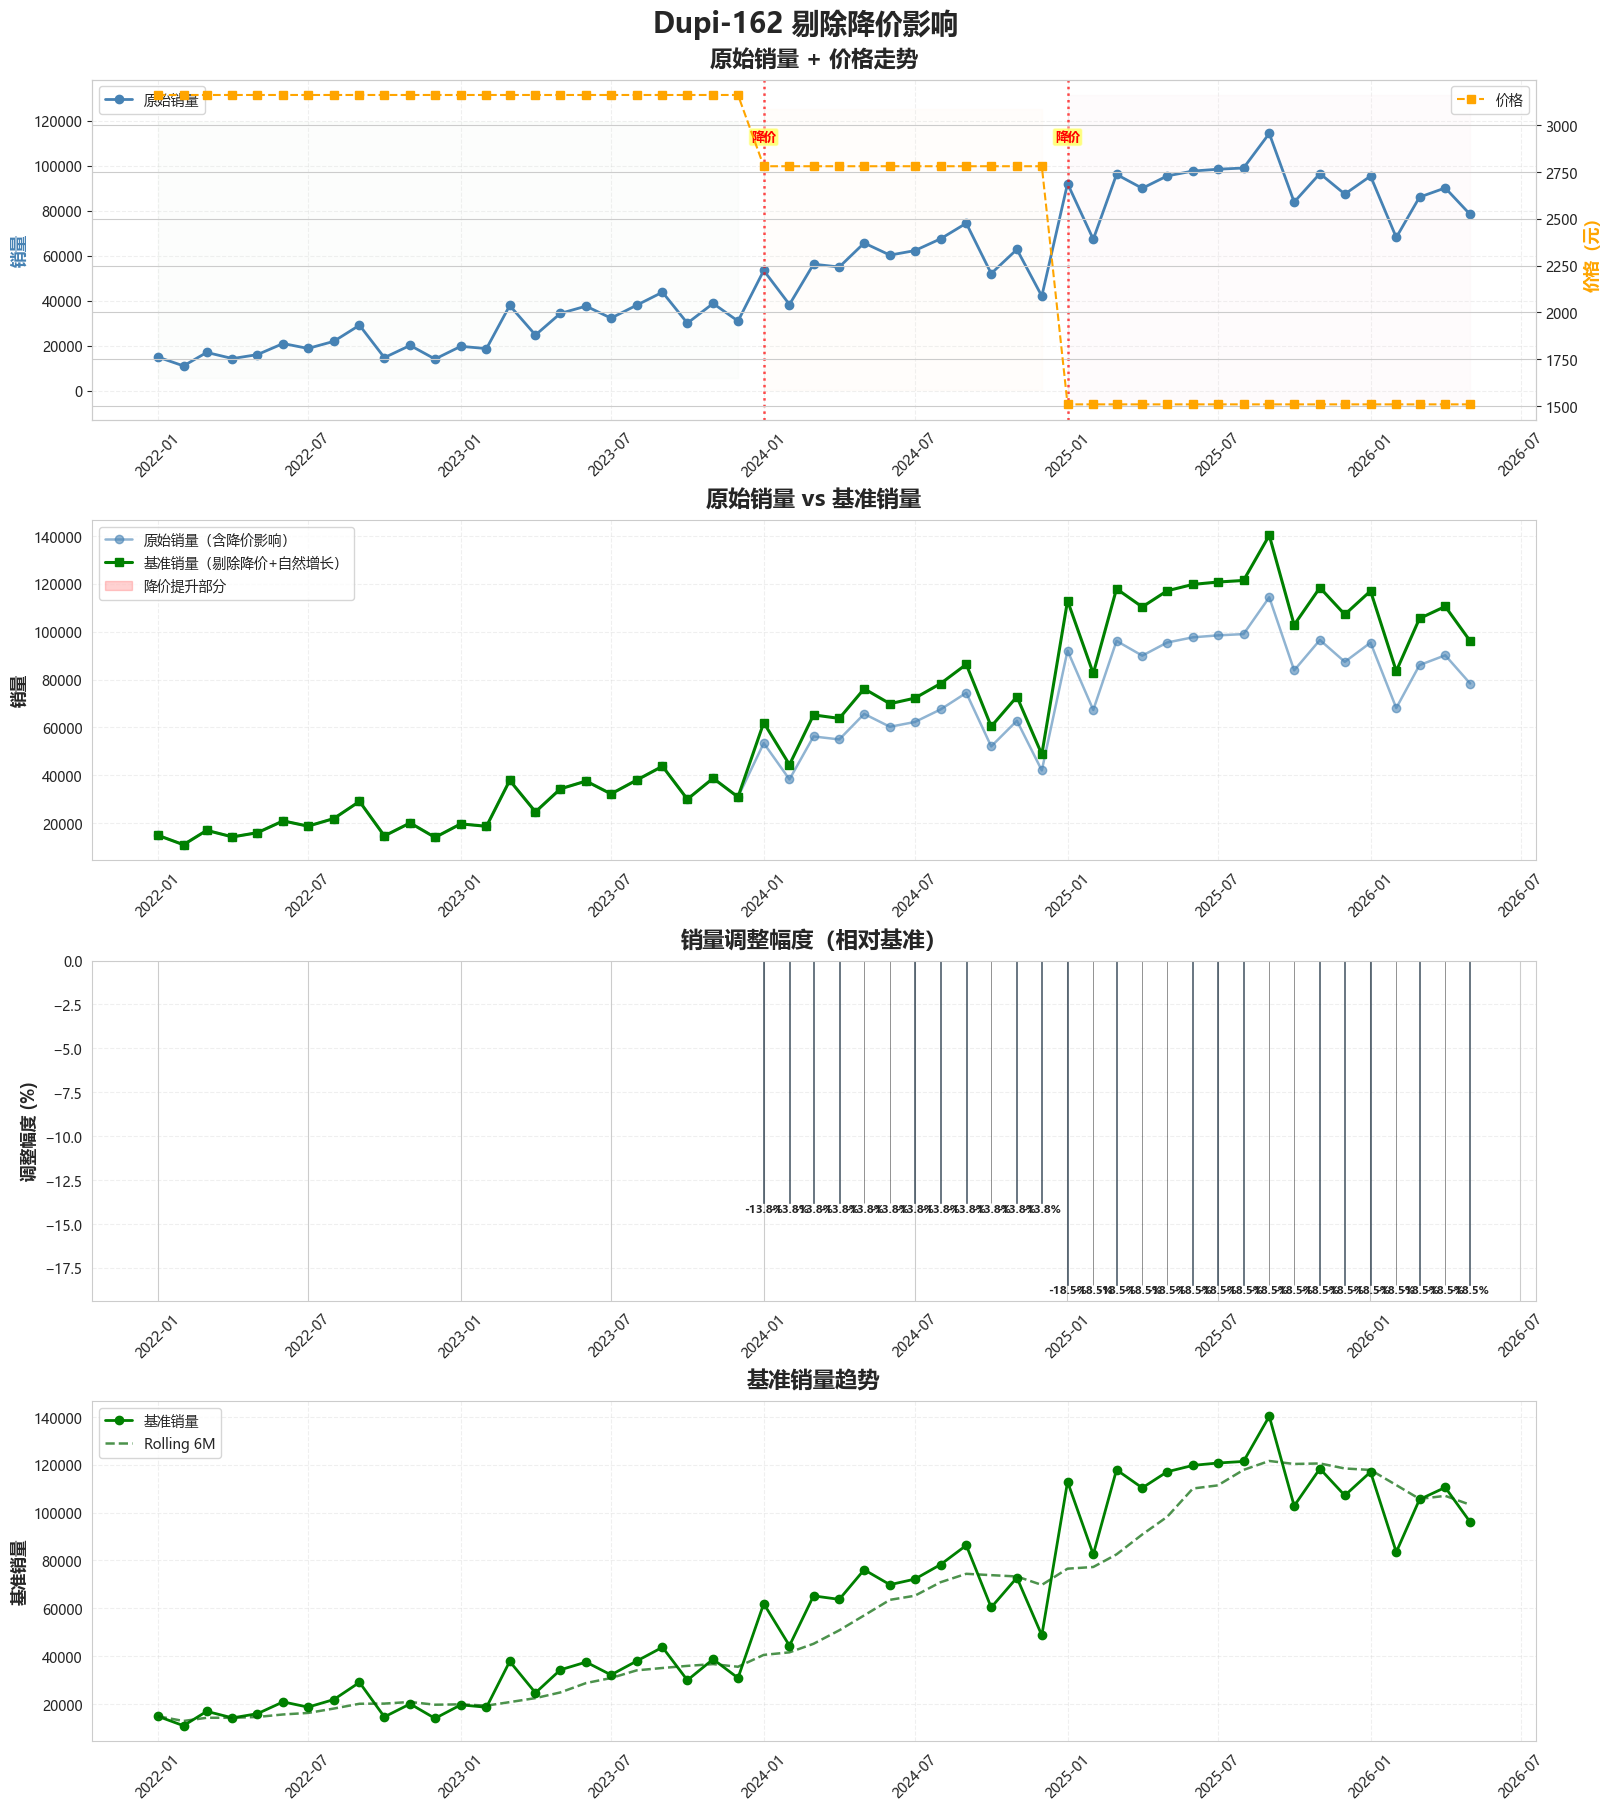

In [10]:
# ── 可视化 ───────────────────────────────────────────────────
ZONE_COLORS  = ['#E8F5E9', '#FFF3E0', '#FCE4EC']
PRICE_DROPS  = df.loc[df['是否降价月'] == 1, 'bizym'].tolist()

fig, axes = plt.subplots(4, 1, figsize=(16, 18), constrained_layout=True)
fig.suptitle('Dupi-162 剔除降价影响', fontsize=20, fontweight='bold')

# 子图1：原始销量 + 价格（双轴）
ax, ax2 = axes[0], axes[0].twinx()
ax.plot(df['bizym'], df['当期总销量'], marker='o', lw=2, color='steelblue', label='原始销量')
ax2.plot(df['bizym'], df['当期价格'], marker='s', lw=1.5, ls='--', color='orange', label='价格')
for d in PRICE_DROPS:
    ax.axvline(d, color='red', ls=':', lw=1.8, alpha=0.7)
    ax.text(d, ax.get_ylim()[1]*0.93, '降价', color='red', fontsize=9,
            ha='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.5))
for gid, gdf in df.groupby('价格区间ID'):
    if gid < len(ZONE_COLORS):
        ax.fill_betweenx(ax.get_ylim(), gdf['bizym'].min(), gdf['bizym'].max(),
                         alpha=0.12, color=ZONE_COLORS[gid])
ax.set_ylabel('销量', color='steelblue'); ax2.set_ylabel('价格（元）', color='orange')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
ax.set_title('原始销量 + 价格走势'); ax.grid(alpha=0.3, ls='--')
ax.tick_params(axis='x', rotation=45)

# 子图2：原始 vs 基准销量
ax = axes[1]
ax.plot(df['bizym'], df['当期总销量'], marker='o', lw=1.8, color='steelblue',
        alpha=0.6, label='原始销量（含降价影响）')
ax.plot(df['bizym'], df['销量_基准'], marker='s', lw=2.2, color='green',
        label='基准销量（剔除降价+自然增长）')
ax.fill_between(df['bizym'], df['当期总销量'], df['销量_基准'],
                where=(df['当期总销量'] > df['销量_基准']),
                alpha=0.18, color='red', label='降价提升部分')
ax.set_ylabel('销量'); ax.legend(loc='upper left')
ax.set_title('原始销量 vs 基准销量'); ax.grid(alpha=0.3, ls='--')
ax.tick_params(axis='x', rotation=45)

# 子图3：调整幅度柱状图
ax = axes[2]
bar_colors = ['red' if x > 10 else 'orange' if x > 0 else 'steelblue'
              for x in df['调整幅度%']]
ax.bar(df['bizym'], df['调整幅度%'], color=bar_colors, alpha=0.75, edgecolor='black', lw=0.4)
for _, row in df[df['调整幅度%'].abs() > 10].iterrows():
    ax.text(row['bizym'], row['调整幅度%'],
            f"{row['调整幅度%']:.1f}%", ha='center',
            va='bottom' if row['调整幅度%'] > 0 else 'top', fontsize=8, fontweight='bold')
ax.axhline(0, color='black', lw=1.2)
ax.set_ylabel('调整幅度 (%)'); ax.set_title('销量调整幅度（相对基准）')
ax.grid(alpha=0.3, ls='--', axis='y'); ax.tick_params(axis='x', rotation=45)

# 子图4：基准销量趋势 + 移动平均
ax = axes[3]
ma = df['销量_基准'].rolling(6, min_periods=1).mean()
ax.plot(df['bizym'], df['销量_基准'], marker='o', lw=2, color='green', label='基准销量')
ax.plot(df['bizym'], ma, lw=1.8, ls='--', color='darkgreen', alpha=0.7, label='Rolling 6M')
ax.set_ylabel('基准销量'); ax.legend(loc='upper left')
ax.set_title('基准销量趋势'); ax.grid(alpha=0.3, ls='--')
ax.tick_params(axis='x', rotation=45)

plt.show()

## 3. 162规格预测

In [11]:
TRAIN_START  = pd.Timestamp('2024-10-01')
TRAIN_END    = pd.Timestamp('2025-10-01')
PRED_START    = pd.Timestamp('2026-04-01')
W_MOM, W_ABS = 0.3, 0.7

### 3.1. 数据准备

In [12]:
keep_cols = ['bizym', '销量_基准', '价格区间ID'] + [
    c for c in ['活跃医疗机构数', '新进活跃医疗机构数'] if c in df.columns
]
df_pcd = (df[keep_cols]
      .rename(columns={'销量_基准': '销量'})
      .assign(年月=lambda d: pd.to_datetime(d['bizym']))
      .copy())

df_pcd['环比增长率'] = df_pcd['销量'].pct_change() * 100
df_pcd['月份'] = df_pcd['年月'].dt.month

print(f"数据范围: {df_pcd['年月'].min():%Y-%m} ~ {df_pcd['年月'].max():%Y-%m}，共{len(df_pcd)}个月")
print(df_pcd[['年月','销量','环比增长率']].to_string(index=False))

数据范围: 2022-01 ~ 2026-05，共53个月
        年月            销量      环比增长率
2022-01-01  14910.500000        NaN
2022-02-01  10964.500000 -26.464572
2022-03-01  16957.500000  54.658215
2022-04-01  14229.500000 -16.087277
2022-05-01  15979.500000  12.298394
2022-06-01  20915.000000  30.886448
2022-07-01  18726.500000 -10.463782
2022-08-01  21877.000000  16.823752
2022-09-01  29061.000000  32.838141
2022-10-01  14643.000000 -49.612883
2022-11-01  20072.500000  37.079150
2022-12-01  14014.500000 -30.180595
2023-01-01  19668.000000  40.340362
2023-02-01  18661.000000  -5.119992
2023-03-01  37830.500000 102.724934
2023-04-01  24692.500000 -34.728592
2023-05-01  34308.750000  38.944011
2023-06-01  37550.500000   9.448756
2023-07-01  32194.500000 -14.263459
2023-08-01  37979.000000  17.967355
2023-09-01  43742.500000  15.175492
2023-10-01  29971.500000 -31.481968
2023-11-01  38739.000000  29.252790
2023-12-01  30899.500000 -20.236712
2024-01-01  61953.495130 100.499992
2024-02-01  44394.320291 -28.34250

### 3.2. 特征工程

In [13]:
def _lookup(df, dates, col):
    """批量从df取指定日期列表的col值，缺失补nan"""
    idx = df.set_index('年月')[col]
    return [idx.get(d, np.nan) for d in dates]

def build_features(df, target_date):
    """
    为指定预测起点构建特征向量及目标值
    返回: features(dict), targets_abs(list[6]), targets_mom(list[6]), future_months
    """
    future_months  = pd.date_range(target_date + pd.DateOffset(months=1), periods=6, freq='MS')
    hist           = df[df['年月'] <= target_date]
    recent_dates   = pd.date_range(target_date - pd.DateOffset(months=5), periods=6, freq='MS')
    ly_dates       = pd.date_range(target_date - pd.DateOffset(months=11), periods=6, freq='MS')
    has_active     = '活跃医疗机构数' in df.columns
    has_new_active = '新进活跃医疗机构数' in df.columns

    # 前6个月 & 去年同期
    rec_qty  = _lookup(hist, recent_dates, '销量')
    rec_mom  = _lookup(hist, recent_dates, '环比增长率')
    ly_qty   = _lookup(hist, ly_dates,     '销量')
    ly_mom   = _lookup(hist, ly_dates,     '环比增长率')
    rec_act  = _lookup(hist, recent_dates, '活跃医疗机构数')    if has_active     else [np.nan]*6
    rec_nact = _lookup(hist, recent_dates, '新进活跃医疗机构数') if has_new_active else [np.nan]*6

    # 线性斜率
    def _slope(vals):
        idx = [i for i, v in enumerate(vals) if not np.isnan(v)]
        if len(idx) < 2: return np.nan, np.nan
        s, _, r, _, _ = stats.linregress(idx, [vals[i] for i in idx])
        return s, r

    rec_slope, rec_r = _slope(rec_qty)
    ly_slope,  _     = _slope(ly_qty)

    # 历史同月环比统计
    future_mnums = [m.month for m in future_months]
    hist_mom_med = [
        hist[hist['月份'] == mn]['环比增长率'].dropna().median()
        if hist[hist['月份'] == mn]['环比增长率'].notna().any() else np.nan
        for mn in future_mnums
    ]

    base_qty  = hist.loc[hist['年月'] == target_date, '销量'].values
    base_qty  = base_qty[0] if len(base_qty) else np.nan
    base_act  = hist.loc[hist['年月'] == target_date, '活跃医疗机构数'].values[0]  if has_active     else np.nan
    base_nact = hist.loc[hist['年月'] == target_date, '新进活跃医疗机构数'].values[0] if has_new_active else np.nan

    abbrs = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
    feat = {
        # 近期汇总
        'rec_销量_均值': np.nanmean(rec_qty),  'rec_销量_总和': np.nansum(rec_qty),
        'rec_销量_标准差': np.nanstd(rec_qty), 'rec_环比_均值': np.nanmean(rec_mom),
        'rec_环比_中位数': np.nanmedian(rec_mom), 'rec_整体斜率': rec_slope, 'rec_R方': rec_r,
        # 去年同期
        'ly_销量_均值': np.nanmean(ly_qty), 'ly_环比_均值': np.nanmean(ly_mom), 'ly_整体斜率': ly_slope,
        # 起点
        # 'base_销量': base_qty,
        'base_活跃机构数': base_act, 'base_新进活跃机构数': base_nact,
        # 活跃机构汇总
        'rec_活跃机构_均值': np.nanmean(rec_act),  'rec_活跃机构_总和': np.nansum(rec_act),
        'rec_新进活跃机构_均值': np.nanmean(rec_nact), 'rec_新进活跃机构_总和': np.nansum(rec_nact),
        # 季节性
        '未来_起始月': future_mnums[0], '未来_结束月': future_mnums[-1],
    }
    
    # 逐月细粒度
    for i in range(6):
        feat[f'rec_M{i+1}_销量'] = rec_qty[i]
        feat[f'rec_M{i+1}_环比'] = rec_mom[i]
        feat[f'future_M{i+1}_hist_mom_median'] = hist_mom_med[i]
        for m in range(1, 13):
            feat[f'future_M{i+1}_is_{abbrs[m-1]}'] = int(future_mnums[i] == m)

    # 目标：绝对值 & 环比
    full_idx  = df.set_index('年月')['销量']
    tgt_abs   = [full_idx.get(m, np.nan) for m in future_months]
    tgt_mom, prev = [], base_qty
    for s in tgt_abs:
        tgt_mom.append((s - prev) / prev * 100 if not (np.isnan(s) or np.isnan(prev) or prev == 0) else np.nan)
        if not np.isnan(s): prev = s

    return feat, tgt_abs, tgt_mom, list(future_months)

### 3.3. 训练数据

In [14]:
# ── 训练样本 ──────────────────────────────────────────────────
records = [
    build_features(df_pcd, d)
    for d in pd.date_range(TRAIN_START, TRAIN_END, freq='MS')
]
records = [(f, a, m, _) for f, a, m, _ in records
           if not any(np.isnan(a)) and not any(np.isnan(m))]

X_raw     = pd.DataFrame([r[0] for r in records])
y_abs     = np.array([r[1] for r in records])
y_mom     = np.array([r[2] for r in records])
print(f"训练样本: {len(X_raw)} 条，特征维度: {X_raw.shape[1]}")

# ── 缺失值填充 ────────────────────────────────────────────────
fill_vals = {}
X = X_raw.copy()
for col in X.columns:
    if X[col].isna().all():
        X[col], fill_vals[col] = 0, 0
    elif '环比' in col or '斜率' in col or 'R方' in col:
        v = X[col].median() if '环比' in col else 0
        X[col], fill_vals[col] = X[col].fillna(v), v
    else:
        v = X[col].mean()
        X[col], fill_vals[col] = X[col].fillna(v), v

# ── 标准化 ────────────────────────────────────────────────
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("缺失值填充 & 标准化完成")
print(X.describe().T[['mean','std','min','max']].round(2))

训练样本: 13 条，特征维度: 108
缺失值填充 & 标准化完成
                       mean        std        min        max
rec_销量_均值          94130.86   19883.99   69790.93  121581.54
rec_销量_总和         564785.14  119303.91  418745.56  729489.27
rec_销量_标准差         14944.08    7454.59    3683.39   25498.44
rec_环比_均值              9.59       9.66      -3.42      24.94
rec_环比_中位数             2.53       4.70      -8.32       9.35
...                     ...        ...        ...        ...
future_M6_is_aug       0.08       0.28       0.00       1.00
future_M6_is_sep       0.08       0.28       0.00       1.00
future_M6_is_oct       0.08       0.28       0.00       1.00
future_M6_is_nov       0.08       0.28       0.00       1.00
future_M6_is_dec       0.08       0.28       0.00       1.00

[108 rows x 4 columns]


### 3.4. 训练&预测

In [15]:
# ── 训练 Ridge 模型 ───────────────────────────────────────────
models_abs = [Ridge(alpha=5.0).fit(X_scaled, y_abs[:, i]) for i in range(6)]
models_mom = [Ridge(alpha=5.0).fit(X_scaled, y_mom[:, i]) for i in range(6)]
print("模型训练完成 (Ridge alpha=5.0)")

# ── 预测特征 ──────────────────────────────────────────────────
feat_pred, _, _, future_months = build_features(df_pcd, PRED_START)
X_pred = pd.DataFrame([feat_pred]).reindex(columns=X.columns)
for col in X_pred.columns:
    X_pred[col] = X_pred[col].fillna(fill_vals.get(col, 0))
X_pred_scaled = scaler.transform(X_pred)

# ── 预测 & 混合 ───────────────────────────────────────────────
pred_abs  = np.array([m.predict(X_pred_scaled)[0] for m in models_abs])
pred_mom  = np.array([m.predict(X_pred_scaled)[0] for m in models_mom])

base_sale = df_pcd.loc[df_pcd['年月'] == PRED_START, '销量'].values[0]
pred_from_mom, cur = [], base_sale
for r in pred_mom:
    cur = cur * (1 + r / 100)
    pred_from_mom.append(cur)
pred_from_mom = np.array(pred_from_mom)

pred_base = W_MOM * pred_from_mom + W_ABS * pred_abs  # 基准销量预测

模型训练完成 (Ridge alpha=5.0)


### 3.5. 还原销量

In [16]:
# ── 还原实际销量 ──────────────────────────────────────────────
price_mult  = df_coef.loc[df_coef.index.max(), '价格效应倍数']
pred_actual = pred_base * price_mult

# ── 打印结果 ──────────────────────────────────────────────────
base_actual = df.loc[df['bizym'] == PRED_START, '当期总销量'].values[0]
print(f"\n价格效应倍数: {price_mult:.2f}x  |  权重: 环比{W_MOM} + 绝对值{W_ABS}")
print(f"\n{'月份':<10} {'基准销量':>12} {'实际销量':>12} {'环比%':>8}")
print("-" * 46)
for i, m in enumerate(future_months):
    prev = base_actual if i == 0 else pred_actual[i-1]
    mom  = (pred_actual[i] - prev) / prev * 100
    print(f"{m:%Y-%m}    {pred_base[i]:>12.0f} {pred_actual[i]:>12.0f} {mom:>8.1f}%")
print("-" * 46)
print(f"{'6个月合计':<10} {pred_base.sum():>12.0f} {pred_actual.sum():>12.0f}")


价格效应倍数: 0.82x  |  权重: 环比0.3 + 绝对值0.7

月份                 基准销量         实际销量      环比%
----------------------------------------------
2026-05          131490       107213     19.0%
2026-06          144305       117662      9.7%
2026-07          103289        84218    -28.4%
2026-08          101204        82518     -2.0%
2026-09          110934        90452      9.6%
2026-10           90638        73903    -18.3%
----------------------------------------------
6个月合计            681859       555966


### 3.6. 可视化观察合理性

In [19]:
qty_idx = df.set_index('bizym')['当期总销量']

# 自动定位去年同期6个月
ly_months  = [m - pd.DateOffset(years=1) for m in future_months]
ly_sales   = np.array([qty_idx.get(m, np.nan) for m in ly_months])

# ── 打印同期对比分析 ──────────────────────────────────────────
recent_3m_avg = qty_idx.iloc[-3:].mean()  # 近3月均值

print(f"\n近3月基准销量均值: {recent_3m_avg:,.0f}")
print(f"\n{'月份':<10} {'预测基准':>10} {'去年同期':>10} {'YoY%':>8} {'vs近3月%':>10}")
print("-" * 52)
for i, m in enumerate(future_months):
    ly  = ly_sales[i]
    yoy = (pred_actual[i] / ly - 1) * 100 if not np.isnan(ly) else float('nan')
    vs3 = (pred_actual[i] / recent_3m_avg - 1) * 100
    yoy_str = f"{yoy:>8.1f}%" if not np.isnan(yoy) else f"{'N/A':>8}"
    print(f"{m:%Y-%m}    {pred_actual[i]:>10.0f} {ly if not np.isnan(ly) else 0:>10.0f} {yoy_str} {vs3:>9.1f}%")
print("-" * 52)
print(f"{'6月均值':<10} {pred_actual.mean():>10.0f} "
      f"{np.nanmean(ly_sales):>10.0f} "
      f"{(pred_actual.mean()/np.nanmean(ly_sales)-1)*100:>8.1f}% "
      f"{(pred_actual.mean()/recent_3m_avg-1)*100:>9.1f}%")


近3月基准销量均值: 84,822

月份               预测基准       去年同期     YoY%     vs近3月%
----------------------------------------------------
2026-05        107213      95456     12.3%      26.4%
2026-06        117662      97626     20.5%      38.7%
2026-07         84218      98435    -14.4%      -0.7%
2026-08         82518      98973    -16.6%      -2.7%
2026-09         90452     114350    -20.9%       6.6%
2026-10         73903      83824    -11.8%     -12.9%
----------------------------------------------------
6月均值            92661      98111     -5.6%       9.2%


In [20]:
# 历史数据
plot_df_162 = df[
    (df['bizym']<=PRED_START) & 
    (df['bizym']>=pd.Timestamp('2024-01-01'))
][['bizym', '当期总销量']].copy().rename(columns={'当期总销量': 'qty'})
plot_df_162['年份'] = plot_df_162['bizym'].dt.year
plot_df_162['月份'] = plot_df_162['bizym'].dt.month
plot_df_162['类型'] = '历史实际值'

# 添加预测数据
pred_data = pd.DataFrame({
    'bizym': future_months,
    'qty': pred_actual,
    '年份': [m.year for m in future_months],
    '月份': [m.month for m in future_months],
    '类型': '未来预测值'
})
plot_df_162 = pd.concat([plot_df_162, pred_data], ignore_index=True)

# 计算YoY
plot_df_162 = plot_df_162.sort_values(['月份', '年份'])
yoy_list = []
for month in range(1, 13):
    month_data = plot_df_162[plot_df_162['月份'] == month].sort_values('年份').copy()
    month_data['YoY'] = month_data['qty'].pct_change() * 100
    yoy_list.append(month_data)

plot_df_162 = pd.concat(yoy_list, ignore_index=True).sort_values('bizym')

# 计算MoM
plot_df_162['mom'] = plot_df_162['qty'].pct_change()
plot_df_162

,bizym,qty,年份,月份,类型,YoY,mom
0,2024-01-01,53403.000000,2024,1,历史实际值,NaN,NaN
3,2024-02-01,38267.250000,2024,2,历史实际值,NaN,-0.283425
6,2024-03-01,56205.500000,2024,3,历史实际值,NaN,0.468762
9,2024-04-01,54952.000000,2024,4,历史实际值,NaN,-0.022302
12,2024-05-01,65626.000000,2024,5,历史实际值,NaN,0.194242
15,2024-06-01,60242.750000,2024,6,历史实际值,NaN,-0.082029
18,2024-07-01,62239.000000,2024,7,历史实际值,NaN,0.033137
21,2024-08-01,67481.000000,2024,8,历史实际值,NaN,0.084224
24,2024-09-01,74416.000000,2024,9,历史实际值,NaN,0.102770
27,2024-10-01,52040.000000,2024,10,历史实际值,NaN,-0.300688


In [21]:
fig = px.scatter(data_frame=plot_df_162, x=plot_df_162['bizym'], y=plot_df_162['qty'], color_discrete_sequence=['yellowgreen'])
fig.add_trace(go.Scatter(x=plot_df_162[plot_df_162['类型']=='历史实际值']['bizym'], 
                        y=plot_df_162[plot_df_162['类型']=='历史实际值']['qty'], 
                        mode='lines', 
                        line=dict(color='purple', width=2),
                        showlegend=False
                        ))
fig.add_trace(go.Scatter(x=plot_df_162.iloc[-7:, 0], 
                        y=plot_df_162.iloc[-7:, 1], 
                        mode='lines', 
                        line=dict(color='royalblue', width=2),
                        showlegend=False
                        ))

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2025-01-01'), x1=pd.Timestamp('2025-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",  # 关键：yref=paper 让 y 坐标用 0-1 相对值
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)

fig.add_shape(
    type="line",
    x0=pd.Timestamp('2026-01-01'), x1=pd.Timestamp('2026-01-01'),
    y0=0, y1=0.95,
    xref="x", yref="paper",
    line=dict(color='#E74C3C', width=2, dash="dash"),
    opacity=0.5
)


fig.add_annotation(
    x=pd.Timestamp('2025-01-01'), y=1,
    xref="x", yref="paper",
    text="2025", showarrow=False,
    yshift=5,  # 文字位置稍微上移
    font=dict(size=12, color='#E74C3C')
)

fig.add_annotation(
    x=pd.Timestamp('2026-01-01'), y=1,
    xref="x", yref="paper",
    text="2026", showarrow=False,
    yshift=5,
    font=dict(size=12, color='#E74C3C')
)


fig.update_xaxes(title='YYYYMM')
fig.update_yaxes(title='Sellin Qty')
fig.update_layout(template='simple_white',
                title='Dupi 300mg (162)',
                xaxis_tickangle=45,
                width=800, 
                height=400 )

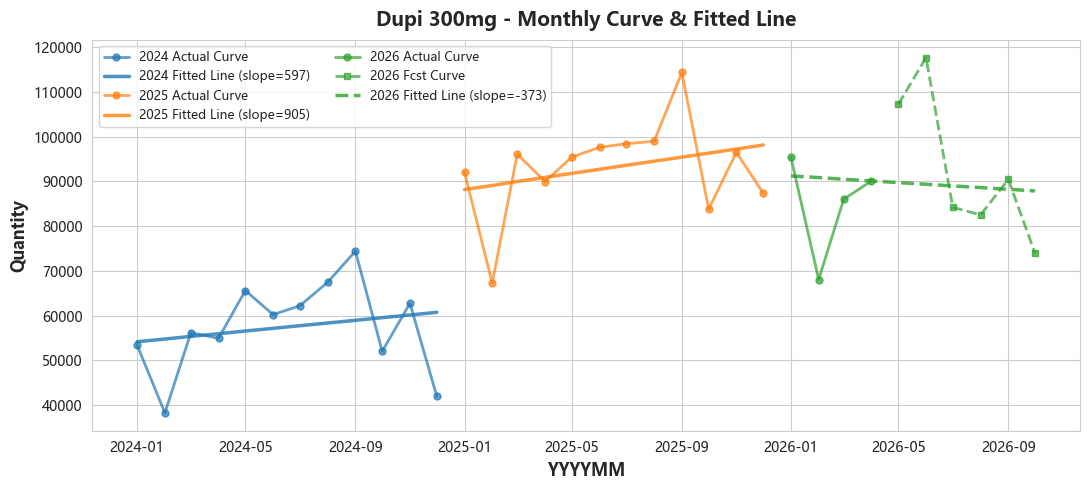

In [22]:
fit_results = {}
years = sorted(plot_df_162['年份'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for year in years:
    year_df = plot_df_162[plot_df_162['年份'] == year].copy()
    
    if len(year_df) > 1:
        year_df['年内序号'] = range(len(year_df))
        x_year = year_df['年内序号'].values
        y_year = year_df['qty'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_year, y_year)
        y_fit = slope * x_year + intercept
        
        fit_results[year] = {
            'df': year_df,
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'y_fit': y_fit,
            'x': x_year,
            'y': y_year
        }

for i, year in enumerate(years):
    year_data = plot_df_162[plot_df_162['年份'] == year].sort_values('bizym')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        plt.plot(hist_data['bizym'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year} Actual Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year) > 0:
        plt.plot(pred_data_year['bizym'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', label=f'{year} Fcst Curve', 
                color=color, markersize=5, alpha=0.7)
    
    if year in fit_results:
        result = fit_results[year]
        has_pred = (year_data['类型'] == '未来预测值').any()
        line_style = '--' if has_pred else '-'
        
        plt.plot(result['df']['bizym'], result['y_fit'], 
                linestyle=line_style, linewidth=2.5, color=color, 
                label=f'{year} Fitted Line (slope={result["slope"]:.0f})',
                alpha=0.8)

plt.xlabel('YYYYMM', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title('Dupi 300mg - Monthly Curve & Fitted Line', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

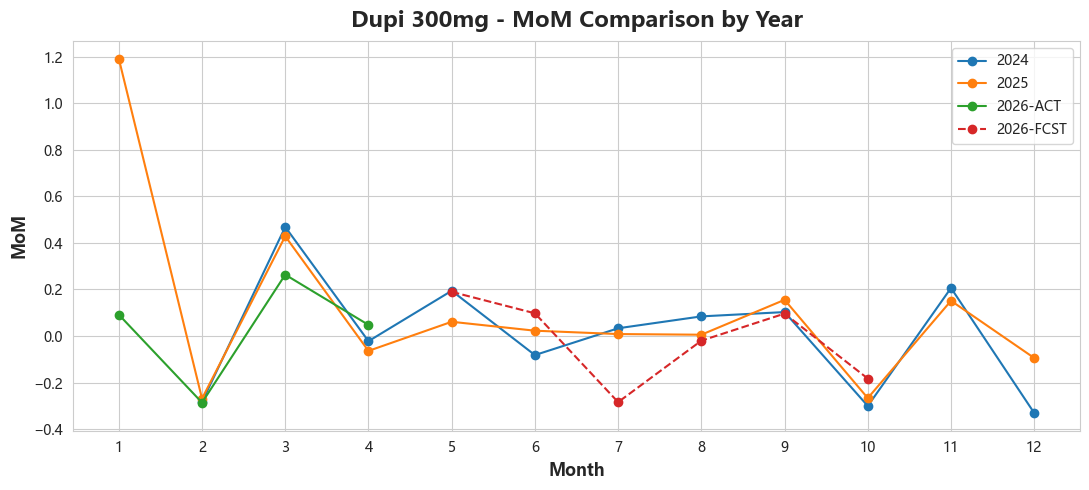

In [23]:
for y in sorted(plot_df_162["年份"].unique()):
    sub = plot_df_162[plot_df_162["年份"] == y].sort_values("月份")
    if y==2026:
        plt.plot(sub[sub['类型'] == '历史实际值']["月份"], sub[sub['类型'] == '历史实际值']["mom"], label=str(y)+'-ACT', marker='o')
        plt.plot(sub[sub['类型'] == '未来预测值']["月份"], sub[sub['类型'] == '未来预测值']["mom"], label=str(y)+'-FCST', marker='o',linestyle='--')
    else:
        plt.plot(sub["月份"], sub["mom"], label=str(y), marker='o')

plt.xlabel("Month")
plt.ylabel("MoM")
plt.title("Dupi 300mg - MoM Comparison by Year")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()